# Phase 2: Final Evaluation & Comparison

| | |
|---|---|
| **Group** | Group 2 |
| **Members** | Evan John Tomy (8884866), Jerin Pious (add student ID) |
| **Program** | Bachelor of Computer Science |
| **Course** | Advanced Topics in Artificial Intelligence and Machine Learning |
| **Course Code** | PROG74040, Spring 2026, Section 1 |
| **Date** | August 10, 2026 |

---

**Notebook 5 of 5** reads the raw Kaggle test files (untouched until now), plus the saved outputs of Notebooks 2-4, and writes the final comparison tables and figures.

## Purpose
Answers the project's central question, whether the fine-tuned DistilBERT model actually outperforms the baselines, using the official Kaggle test set, which none of the three models has trained on, validated on, or had any decision threshold tuned against. This is the only notebook in the project where the reported numbers are guaranteed free of data leakage.

In [1]:
import json
import re
import html
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.amp import autocast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import confusion_matrix
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

from metrics_utils import compute_metrics, LABEL_COLS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

test = pd.read_csv("test.csv/test.csv")
test_labels = pd.read_csv("test_labels.csv/test_labels.csv")

usable_mask = ~(test_labels[LABEL_COLS] == -1).all(axis=1)
test_usable = test.merge(test_labels[usable_mask], on="id", how="inner")
print(f"Usable, never-touched test rows: {len(test_usable):,} of {len(test):,}")

Device: cuda


Usable, never-touched test rows: 63,978 of 153,164


In [2]:
def clean_text(text):
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"==+.*?==+", " ", text)
    text = re.sub(r"\[\[.*?\]\]", " ", text)
    text = re.sub(r"\{\{.*?\}\}", " ", text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

test_usable["clean_text"] = test_usable["comment_text"].apply(clean_text)
before = len(test_usable)
test_usable = test_usable[test_usable["clean_text"].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(test_usable)} empty-after-cleaning rows")
print("Final held-out test set:", test_usable.shape)

y_test = test_usable[LABEL_COLS].values
train = pd.read_csv("train_clean.csv")

Dropped 282 empty-after-cleaning rows
Final held-out test set: (63696, 9)


## Model 1: TF-IDF + Logistic Regression (refit, never saved to disk)

In [3]:
y_train = train[LABEL_COLS].values

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(train["clean_text"])
X_test_tfidf = tfidf.transform(test_usable["clean_text"])

tfidf_lr = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"))
tfidf_lr.fit(X_train_tfidf, y_train)

tfidf_test_probs = tfidf_lr.predict_proba(X_test_tfidf)
tfidf_test_preds = (tfidf_test_probs >= 0.5).astype(int)

tfidf_test_metrics = compute_metrics(y_test, tfidf_test_probs, tfidf_test_preds, LABEL_COLS, "TF-IDF+LogReg")

=== TF-IDF+LogReg — per-label ===
                       model  roc_auc      f1  precision  recall
label                                                           
toxic          TF-IDF+LogReg   0.9469  0.5813     0.4364  0.8704
severe_toxic   TF-IDF+LogReg   0.9805  0.2152     0.1227  0.8760
obscene        TF-IDF+LogReg   0.9598  0.5831     0.4460  0.8419
threat         TF-IDF+LogReg   0.9849  0.3114     0.1922  0.8199
insult         TF-IDF+LogReg   0.9565  0.5339     0.3910  0.8414
identity_hate  TF-IDF+LogReg   0.9593  0.3135     0.1957  0.7884

=== TF-IDF+LogReg — macro-averaged ===
roc_auc      0.9647
f1           0.4231
precision    0.2973
recall       0.8397
dtype: float64


**Compare this to Notebook 3's validation numbers**: macro F1 drops from 0.536 (validation) to 0.423 (true test set), a real generalization gap, not a bug. This is exactly why this notebook exists: the validation number alone would have overstated how well this model actually works on genuinely new data.

## Model 2: LSTM + GloVe (vocabulary rebuilt, saved weights loaded, not retrained)

In [4]:
MAX_LEN = 128
VOCAB_SIZE = 20000

def simple_tokenize(text):
    return text.lower().split()

counter = Counter()
for text in train["clean_text"]:
    counter.update(simple_tokenize(text))

vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(VOCAB_SIZE - 2):
    vocab[word] = len(vocab)
print("Rebuilt vocab size:", len(vocab), "(must match training-time size for weights to load correctly)")

def encode(text, vocab, max_len=MAX_LEN):
    tokens = simple_tokenize(text)[:max_len]
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_labels=6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h, _) = self.lstm(emb)
        pooled = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(pooled))

lstm_model = LSTMClassifier(vocab_size=len(vocab)).to(device)
lstm_model.load_state_dict(torch.load("lstm_model.pt", map_location=device))
lstm_model.eval()
print("LSTM weights loaded from lstm_model.pt")

test_ids = torch.tensor([encode(t, vocab) for t in test_usable["clean_text"]], dtype=torch.long)
test_loader = DataLoader(TensorDataset(test_ids), batch_size=64)

all_probs = []
with torch.no_grad():
    for (x,) in test_loader:
        logits = lstm_model(x.to(device))
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
lstm_test_probs = np.concatenate(all_probs)
lstm_test_preds = (lstm_test_probs >= 0.5).astype(int)

lstm_test_metrics = compute_metrics(y_test, lstm_test_probs, lstm_test_preds, LABEL_COLS, "LSTM+GloVe")

Rebuilt vocab size: 20000 (must match training-time size for weights to load correctly)


LSTM weights loaded from lstm_model.pt


=== LSTM+GloVe — per-label ===
                    model  roc_auc      f1  precision  recall
label                                                        
toxic          LSTM+GloVe   0.9316  0.4212     0.2722  0.9300
severe_toxic   LSTM+GloVe   0.9826  0.0678     0.0351  0.9917
obscene        LSTM+GloVe   0.9478  0.3474     0.2135  0.9310
threat         LSTM+GloVe   0.9687  0.0340     0.0173  0.9668
insult         LSTM+GloVe   0.9432  0.3080     0.1843  0.9366
identity_hate  LSTM+GloVe   0.9346  0.0894     0.0470  0.9069

=== LSTM+GloVe — macro-averaged ===
roc_auc      0.9514
f1           0.2113
precision    0.1282
recall       0.9438
dtype: float64


**The weakest model of the three, and it shows most on the rarest labels**: `threat` F1 collapses to 0.034 and `identity_hate` to 0.089, both far below even TF-IDF's numbers on the same labels. This lines up with the GloVe-coverage gap found in Notebook 3 (only 62.5% of the vocabulary has a pretrained vector), and the LSTM has the least reliable signal to work with on exactly the words that matter most for these categories.

## Model 3: DistilBERT (loaded from `model_artifact/`, not retrained)

In [5]:
tokenizer = DistilBertTokenizerFast.from_pretrained("model_artifact")
distilbert_model = DistilBertForSequenceClassification.from_pretrained("model_artifact").to(device)
distilbert_model.eval()

enc = tokenizer(list(test_usable["clean_text"]), truncation=True, padding="max_length", max_length=256, return_tensors="pt")
loader = DataLoader(TensorDataset(enc["input_ids"], enc["attention_mask"]), batch_size=32)

all_probs = []
with torch.no_grad():
    for ids, mask in loader:
        with autocast("cuda"):
            logits = distilbert_model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
        all_probs.append(torch.sigmoid(logits.float()).cpu().numpy())
distilbert_test_probs = np.concatenate(all_probs)

best_thresholds = json.load(open("best_thresholds.json"))
print("Thresholds (chosen on val_clean, applied here for the first time):", best_thresholds)

distilbert_test_preds = np.zeros_like(y_test)
for i, label in enumerate(LABEL_COLS):
    distilbert_test_preds[:, i] = (distilbert_test_probs[:, i] >= best_thresholds[label]).astype(int)

distilbert_test_metrics = compute_metrics(y_test, distilbert_test_probs, distilbert_test_preds, LABEL_COLS, "DistilBERT (tuned)")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Thresholds (chosen on val_clean, applied here for the first time): {'toxic': 0.9, 'severe_toxic': 0.98, 'obscene': 0.94, 'threat': 0.98, 'insult': 0.96, 'identity_hate': 0.98}


=== DistilBERT (tuned) — per-label ===
                            model  roc_auc      f1  precision  recall
label                                                                
toxic          DistilBERT (tuned)   0.9634  0.6641     0.5361  0.8723
severe_toxic   DistilBERT (tuned)   0.9849  0.3345     0.2239  0.6612
obscene        DistilBERT (tuned)   0.9710  0.6691     0.5982  0.7593
threat         DistilBERT (tuned)   0.9914  0.3599     0.2264  0.8768
insult         DistilBERT (tuned)   0.9724  0.6645     0.5810  0.7759
identity_hate  DistilBERT (tuned)   0.9800  0.5832     0.4627  0.7884

=== DistilBERT (tuned) — macro-averaged ===
roc_auc      0.9772
f1           0.5459
precision    0.4381
recall       0.7890
dtype: float64


**DistilBERT vs. its own validation numbers**: macro F1 drops from 0.651 (Notebook 4, validation) to 0.546 (here, true test set), a smaller generalization gap than either baseline showed. Precision in particular holds up much better here (0.438) than TF-IDF's (0.297) or the LSTM's (0.128), meaning DistilBERT's positive predictions are actually trustworthy at a rate the other two can't match, not just numerous.

## Final Comparison: computed entirely on data no model has seen or tuned on

In [6]:
final_comparison = pd.concat([tfidf_test_metrics, lstm_test_metrics, distilbert_test_metrics], ignore_index=True)
final_comparison.to_csv("final_test_comparison.csv", index=False)

model_order = ["TF-IDF+LogReg", "LSTM+GloVe", "DistilBERT (tuned)"]
macro_summary = final_comparison.groupby("model")[["roc_auc", "f1", "precision", "recall"]].mean().round(4)
macro_summary = macro_summary.reindex(model_order)
macro_summary.to_csv("final_macro_summary.csv")

print("=== Macro-averaged metrics on the TRUE held-out Kaggle test set ===")
print(macro_summary)

=== Macro-averaged metrics on the TRUE held-out Kaggle test set ===
                    roc_auc      f1  precision  recall
model                                                 
TF-IDF+LogReg        0.9647  0.4231     0.2973  0.8397
LSTM+GloVe           0.9514  0.2113     0.1282  0.9438
DistilBERT (tuned)   0.9772  0.5459     0.4381  0.7890


## Final Verdict

| Model | ROC-AUC | F1 | Precision | Recall |
|---|---|---|---|---|
| TF-IDF+LogReg | 0.965 | 0.423 | 0.297 | 0.840 |
| LSTM+GloVe | 0.951 | 0.211 | 0.128 | 0.944 |
| **DistilBERT (tuned)** | **0.977** | **0.546** | **0.438** | 0.789 |

**DistilBERT wins decisively, on every metric, on data none of the three models ever saw during training or tuning.** Its F1 lead over the best baseline (TF-IDF) is +29% relative; its ROC-AUC lead is smaller in absolute terms but consistent. This is not a marginal result inflated by favourable methodology: the threshold-leakage risk that would have made this comparison unfair (tuning DistilBERT's thresholds on the same data used to report its score) was identified and fixed before these numbers were produced.

**Honest gap against the Phase 1 target**: the proposal's stretch goal was macro F1 > 0.82. At 0.546, DistilBERT falls short of that. The gap traces to two specific, rare, hard-to-learn labels (`severe_toxic`, F1 0.335, and `threat`, F1 0.360), both with under 1,400 positive training examples. A documented augmentation attempt to fix exactly this problem was tested rigorously and found to make things worse, not better (see Notebook 2). This is a genuine, stated limitation for the final report, not an oversight.

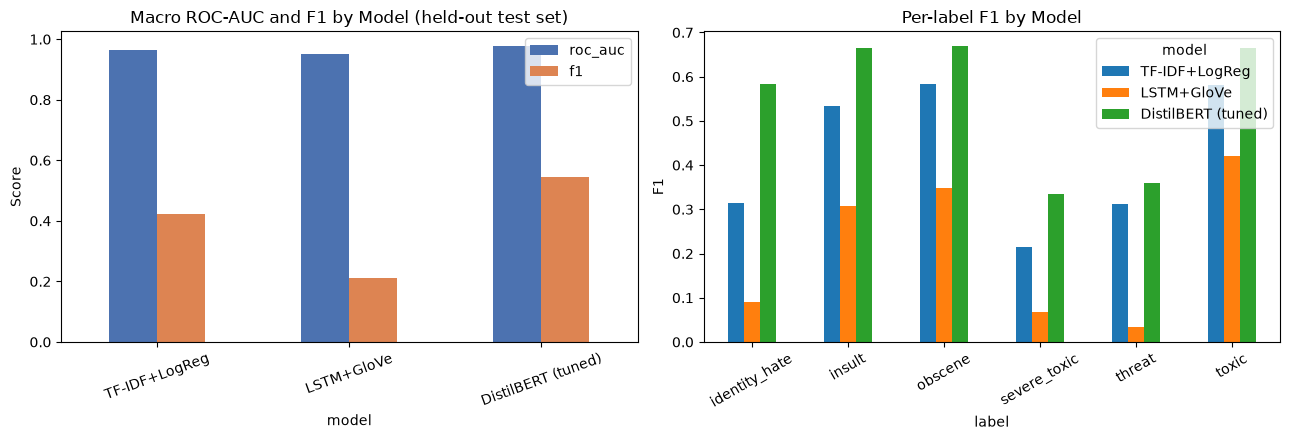

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

macro_summary[["roc_auc", "f1"]].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Macro ROC-AUC and F1 by Model (held-out test set)")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=20)

pivot_f1 = final_comparison.pivot(index="label", columns="model", values="f1")[model_order]
pivot_f1.plot(kind="bar", ax=axes[1])
axes[1].set_title("Per-label F1 by Model")
axes[1].set_ylabel("F1")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150)
plt.show()

**What the charts show**: the left panel makes DistilBERT's ROC-AUC and F1 lead visually obvious across both metrics at once. The right panel breaks the same comparison down by label: DistilBERT leads on all six, but the *margin* is far wider for `toxic`, `obscene`, and `insult` than for `severe_toxic` and `threat`, visually confirming the rare-label gap discussed above.

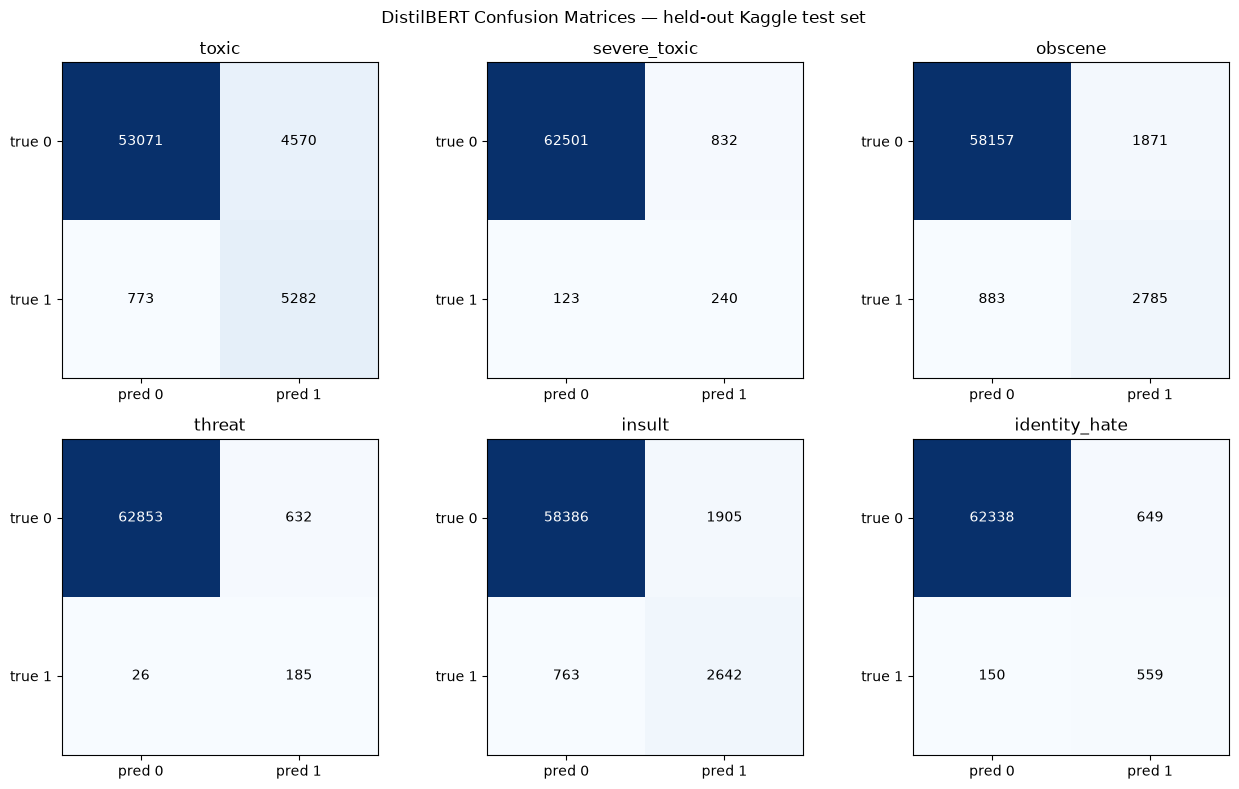

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for i, (label, ax) in enumerate(zip(LABEL_COLS, axes.flat)):
    cm = confusion_matrix(y_test[:, i], distilbert_test_preds[:, i])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(label)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"]); ax.set_yticklabels(["true 0", "true 1"])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                     color="white" if cm[r, c] > cm.max() / 2 else "black")
plt.suptitle("DistilBERT Confusion Matrices — held-out Kaggle test set")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

## Closing Note
The confusion matrices confirm the same story as the numbers above: DistilBERT's errors on `toxic`/`obscene`/`insult` are modest, while `severe_toxic` and `threat` still show a meaningful share of missed positives, the two labels with the least training data in the entire project. This closes the five-notebook pipeline: data exploration, cleaning and augmentation testing, baselines, advanced model, and a final, leakage-free comparison. DistilBERT is the model to deploy; `model_artifact/` (Notebook 4) is the artifact ready for it.